# 📈 Macro-Financial Time-Series Analysis (2014-2024)

**Objective:** Build monthly panel dataset and ARIMAX model to analyze Nifty 50 returns drivers (CPI inflation, RBI repo rate, INR/USD FX).

**Data Sources:**
- Nifty 50: Monthly closing prices (Apr 2014 - Mar 2024)
- CPI: All-India General Index monthly inflation  
- RBI: Repo rate monthly averages
- FX: INR/USD monthly averages

**Methods:** ETL → EDA → Time-series diagnostics → ARIMAX modeling

**Tech Stack:** pandas, numpy, statsmodels, matplotlib, seaborn


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

### DATA CLEANING

In [103]:
#Read all files
infl = pd.read_excel("Inflation Rate.xlsx",header=1)
repo = pd.read_excel("Repo Clean.xlsx",header=0)
fx   = pd.read_excel("Exchange Rate Clean.xlsx", header=0)
nifty= pd.read_excel("NIFTY 50_10 YEARS.xlsx",header=0)

In [104]:
#==============================================================================
# All-India CPI General Index: Monthly Inflation Series 
#==============================================================================

# 1) Filter: All-India General Index (national headline CPI-IW)
infl2 = infl[(infl['State'] == 'ALL India') &
             (infl['Description'] == 'General Index (All Groups)')].copy()

# 2) Create monthly Date column
infl2['Date'] = pd.to_datetime(
    infl2['Year'].astype(int).astype(str) + "-" + infl2['Month'],
    format="%Y-%B"
)

# 3) Sort by Date (chronological order)
infl2 = infl2.sort_values('Date')

# 4) Keep Month_Year label + Combined inflation rate
infl2['Month_Year'] = infl2['Date'].dt.strftime('%b %Y')
infl_m = infl2[['Month_Year', 'Combined']].rename(columns={'Combined': 'Infl_m'})

In [105]:
#==============================================================================
# RBI Repo Rate: Monthly Average Series (Apr 2014 - Mar 2024)
#==============================================================================

# 1) Clean: Convert dates & rates to proper format, sort chronologically
repo['Date'] = pd.to_datetime(repo['Effective Date'])
repo['Repo_Rate'] = pd.to_numeric(repo['Repo Rate'], errors='coerce')
repo = repo.sort_values('Date')

In [106]:
# 2) Forward-fill to daily frequency (standard for policy rates)
daily_repo = repo.set_index('Date').resample('D').ffill()

# 3) Define exact monthly range (FY 2014-15 to FY 2023-24)
month_range = pd.date_range(start='2014-04-30', end='2024-03-31', freq='ME')

# 4) Monthly averages, aligned to range, final format
repo_m_full = (daily_repo
               .resample('ME')
               .mean()
               .reindex(month_range)
               .reset_index()
               .rename(columns={'index': 'Date', 'Repo_Rate': 'Repo_m'}))

repo_m_full['Month_Year'] = repo_m_full['Date'].dt.strftime('%b %Y')
repo_m_full = repo_m_full[['Month_Year', 'Repo_m']]

In [107]:
#==============================================================================
# Nifty 50 Index: Monthly Closing Values [finance:NIFTY 50]
#==============================================================================

# 1) Rename first two columns to standard names
nifty = nifty.rename(columns={
    nifty.columns[0]: 'Date',
    nifty.columns[1]: 'Nifty_50'
})

# 2) Convert Date to datetime, drop invalid dates
nifty['Date'] = pd.to_datetime(nifty['Date'], errors='coerce')
nifty = nifty.dropna(subset=['Date'])

# 3) Set Date index, resample to month-end closes
nifty = nifty.set_index('Date')
nifty_m = nifty.resample('ME').last()

# 4) Add Month_Year label, final clean table
nifty_m['Month_Year'] = nifty_m.index.strftime('%b %Y')
nifty_m = nifty_m[['Month_Year', 'Nifty_50']].reset_index(drop=True)

In [108]:
#==============================================================================
# Monthly Exchange Rate : INR/USD 
#==============================================================================

# Parse strings like "Apr 2014" -> datetime
fx['Date'] = pd.to_datetime(fx['Month'], format='%b %Y')

# Sort by real date
fx = fx.sort_values('Date').reset_index(drop=True)

# Create Month_Year string in the desired format (e.g. "Apr 2014")
fx['Month_Year'] = fx['Date'].dt.strftime('%b %Y')

# Final dataframe with FX column named Fx_m
fx_m = fx[['Date', 'Month_Year', 'USD']].rename(columns={'USD': 'Fx_m'})

### Monthly Macro–Financial Master Panel

In [109]:
#==============================================================================
# Monthly Macro–Financial Master Panel
#==============================================================================

master = (nifty_m[['Month_Year', 'Nifty_50']]
          .merge(infl_m,       on='Month_Year', how='inner')   # CPI inflation
          .merge(repo_m_full,  on='Month_Year', how='inner')   # RBI repo rate
          .merge(fx_m,  on='Month_Year', how='inner'))
master.head()

,Month_Year,Nifty_50,Infl_m,Repo_m,Date,Fx_m
0,Apr 2014,6696.40,8.48,8.0,2014-04-30,60.3566
1,May 2014,7229.95,8.33,8.0,2014-05-31,59.3050
2,Jun 2014,7611.35,6.77,8.0,2014-06-30,59.7307
3,Jul 2014,7721.30,7.39,8.0,2014-07-31,60.0586
4,Aug 2014,7954.35,7.03,8.0,2014-08-31,60.8952


### Descriptive Statistics and Graphs

**Basic descriptive stats**

In [110]:
from scipy.stats import skew
#==============================================================================
# Basic descriptive stats
#==============================================================================

master[['Nifty_50', 'Infl_m', 'Repo_m', 'Fx_m']].describe()

# This table summarizes the central tendency and spread (mean,
# standard deviation, min, max, quartiles) of all main variables.

,Nifty_50,Infl_m,Repo_m,Fx_m
count,118.000000,118.000000,118.000000,118.000000
mean,12366.658051,5.062288,5.952489,71.001684
std,4201.344638,1.492379,1.203859,6.794536
min,6696.400000,1.460000,4.000000,59.305000
25%,8614.787500,4.087500,5.150000,65.220050
50%,11025.475000,5.040000,6.250000,70.732000
75%,16741.562500,6.055000,6.500000,74.854450
max,22326.900000,8.480000,8.000000,83.298000


**Key summary statistics**

- All four variables have 118 monthly observations with no missing values.
- Nifty_50 shows a high average level with large dispersion, while inflation and repo rate stay mostly in a moderate range (around 5–6%). 
- The INR/USD rate averages near 71 and varies meaningfully over time, indicating notable currency movements during the sample.


**Skewness for each variable**

In [111]:
#==============================================================================
# Skewness for each variable
#==============================================================================

for col in ['Nifty_50', 'Infl_m', 'Repo_m', 'Fx_m']:
    print(col, skew(master[col], bias=False))

# Skewness tells us how asymmetric each distribution is; 
# a large positive value confirms right-skew and supports log transforms.

Nifty_50 0.6816920912185133
Infl_m -0.041325352643464465
Repo_m -0.32061620660287127
Fx_m 0.36335428512850476


**Skewness (asymmetry)**

- Nifty_50 is moderately right‑skewed (skew ≈ 0.68), driven by a few high index values in the right tail.  
- Inflation is almost symmetric (skew ≈ 0), while the repo rate shows mild left‑skew.  
- The exchange rate (Fx_m) has mild right‑skew, indicating a longer tail of higher INR/USD values.


**Boxplots for Key Financial Variables**

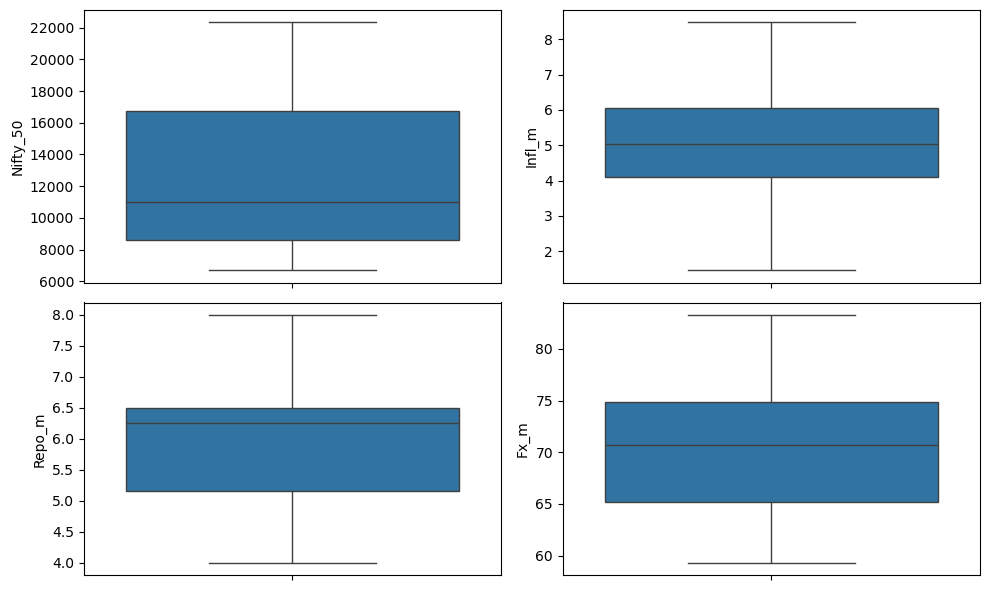

In [112]:

# ====================================================
# Boxplots for Key Financial Variables
# ====================================================

# Create a 2×2 grid of subplots and set figure size
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Draw boxplot of Nifty_50 index values
sns.boxplot(y=master['Nifty_50'], ax=axes[0, 0])

# Draw boxplot of monthly inflation (Infl_m)
sns.boxplot(y=master['Infl_m'], ax=axes[0, 1])

# Draw boxplot of repo rate (Repo_m)
sns.boxplot(y=master['Repo_m'], ax=axes[1, 0])

# Draw boxplot of exchange rate (Fx_m)
sns.boxplot(y=master['Fx_m'], ax=axes[1, 1])

# Adjust spacing so subplots do not overlap
plt.tight_layout()

# Boxplots help us visually detect extreme values (outliers) that
# might overly influence the regression estimates.

**Boxplots (level and dispersion)**

- Nifty_50 shows a higher level and wider spread with a longer upper whisker, consistent with right‑skew and some high index values.  
- Inflation and repo rate boxes are tight and roughly symmetric, indicating a moderate, stable range with few extreme policy moves.  
- FX has a wider box and slightly longer upper whisker, pointing to more variability and occasional periods of higher INR/USD.


**Histogram for Nifty_50**

Text(0, 0.5, 'Frequency')

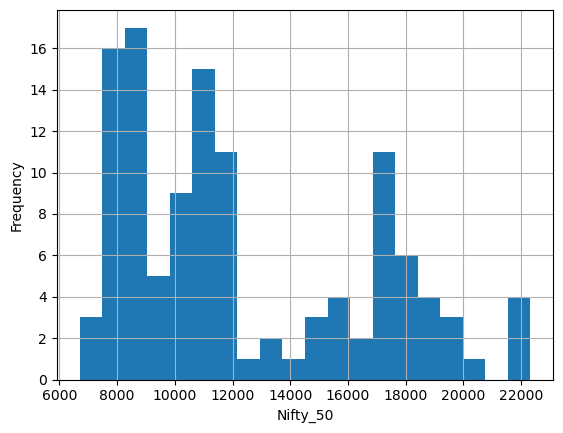

In [113]:
#==============================================================================
# Histogram for Nifty_50
#==============================================================================

# Plot histogram of the Nifty_50 index with 20 bins to see its distribution
master['Nifty_50'].hist(bins=20)

# Label the x-axis with the variable name
plt.xlabel('Nifty_50')

# Label the y-axis to show frequency of observations in each bin
plt.ylabel('Frequency')

**Nifty_50 histogram**

- Most observations lie between roughly 7,000 and 12,000, with fewer but occasional very high values, giving a right‑skewed shape.  
- The right‑skew and extreme highs suggest that a log or similar transformation could help stabilise variance and move the distribution closer to normal.


**Time-Series Plots for Key Macro-Financial Variables**

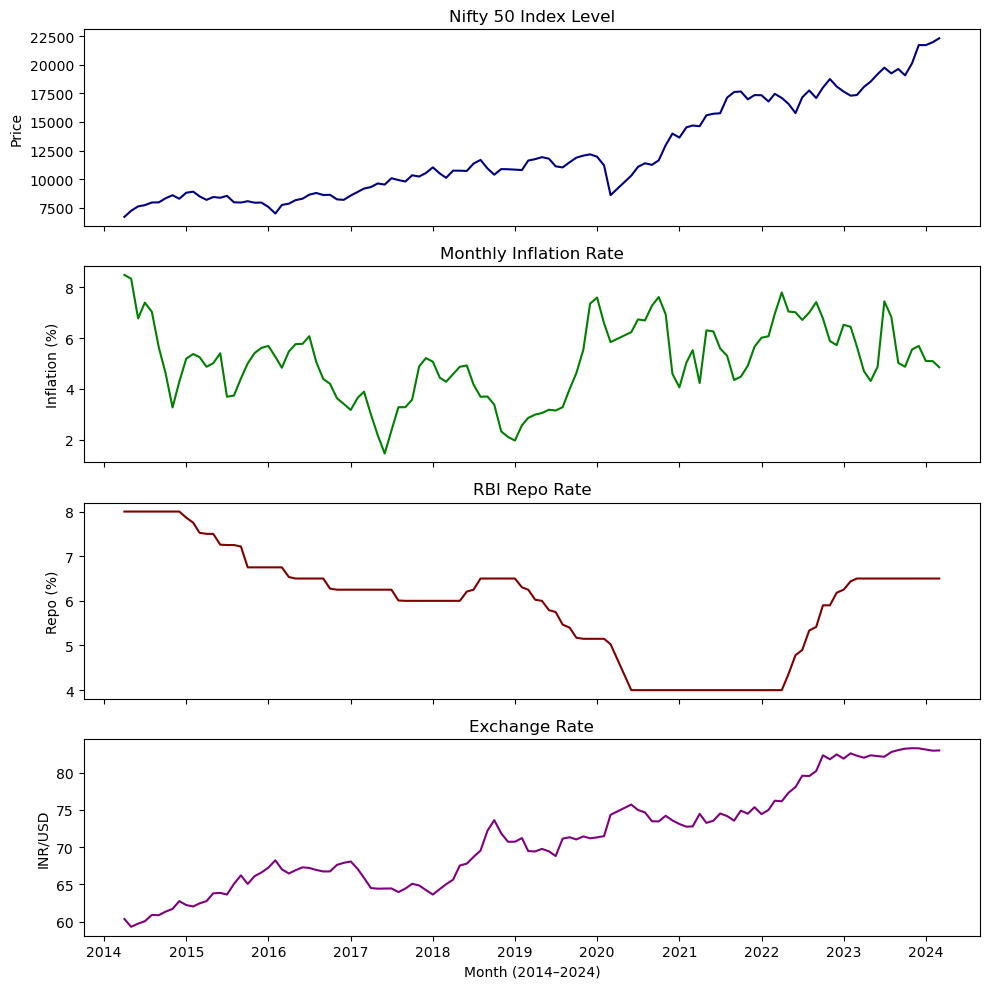

In [114]:
#==============================================================================
# Time-Series Plots for Key Macro-Financial Variables
#==============================================================================

# Convert Month_Year to datetime so that it can be used as a proper time index
master['Month_Year'] = pd.to_datetime(master['Month_Year'], format='%b %Y')

# Sort the dataset chronologically and reset the row index
master = master.sort_values('Month_Year').reset_index(drop=True)

# Create a dedicated Date column (same as Month_Year) for plotting on the x-axis
master['Date'] = pd.to_datetime(master['Month_Year'], format='%b %Y')

# Create a 4×1 grid of subplots sharing the same x-axis (time)
fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# Plot Nifty 50 index level over time
ax[0].plot(master['Date'], master['Nifty_50'], color='navy')
ax[0].set_ylabel('Price')
ax[0].set_title('Nifty 50 Index Level')

# Plot monthly inflation rate over time
ax[1].plot(master['Date'], master['Infl_m'], color='green')
ax[1].set_ylabel('Inflation (%)')
ax[1].set_title('Monthly Inflation Rate')

# Plot RBI repo rate over time
ax[2].plot(master['Date'], master['Repo_m'], color='maroon')
ax[2].set_ylabel('Repo (%)')
ax[2].set_title('RBI Repo Rate')

# Plot INR/USD exchange rate over time
ax[3].plot(master['Date'], master['Fx_m'], color='purple')
ax[3].set_ylabel('INR/USD')
ax[3].set_title('Exchange Rate')
ax[3].set_xlabel('Month (2014–2024)')

# Adjust layout so titles and labels do not overlap
plt.tight_layout()
plt.show()



**Time paths of key variables (2014–2024)**

- Nifty 50 shows a strong upward trend over the decade, with temporary drawdowns but higher highs in recent years.  
- Inflation fluctuates within a moderate band, while the repo rate adjusts gradually in discrete steps rather than sharp jumps.  
- The INR/USD exchange rate trends weaker on average (higher INR/USD), especially after 2018, indicating episodes of currency depreciation.


**Scatter plots of log(Nifty_50) against each regressor**

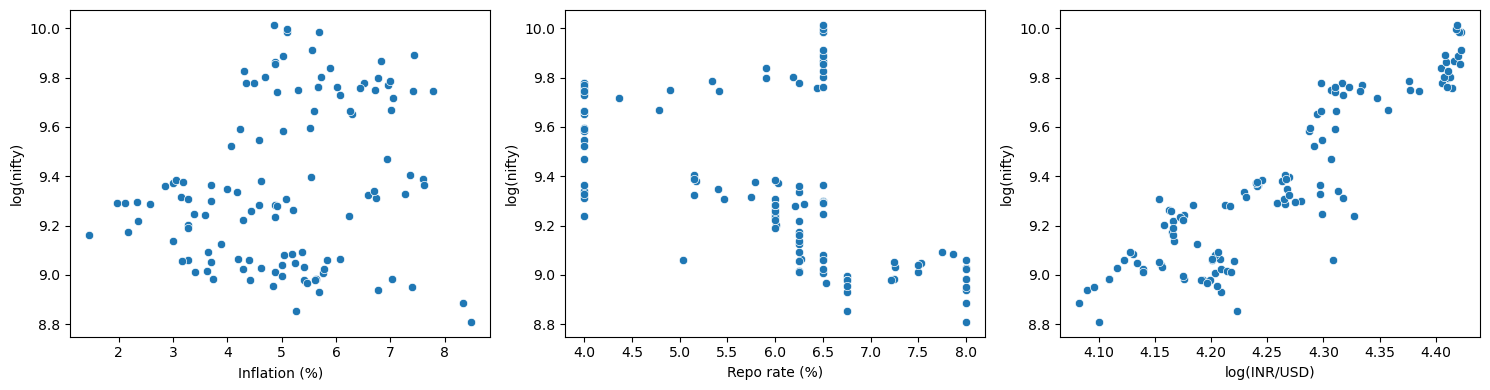

In [115]:
#==============================================================================
# Scatter plots of log(Nifty_50) against each regressor
#==============================================================================

master['log_nifty'] = np.log(master['Nifty_50'])
master['log_Fx'] = np.log(master['Fx_m'])

# Create a 1×3 grid of subplots to compare relationships side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter of inflation vs log(Nifty_50) to see how equity prices move with prices
sns.scatterplot(x='Infl_m', y='log_nifty', data=master, ax=axes[0])
axes[0].set_xlabel('Inflation (%)')
axes[0].set_ylabel('log(nifty)')

# Scatter of repo rate vs log(Nifty_50) to inspect how policy rate relates to the index
sns.scatterplot(x='Repo_m', y='log_nifty', data=master, ax=axes[1])
axes[1].set_xlabel('Repo rate (%)')
axes[1].set_ylabel('log(nifty)')

# Scatter of log exchange rate vs log(Nifty_50) to study co-movement with the currency
sns.scatterplot(x='log_Fx', y='log_nifty', data=master, ax=axes[2])
axes[2].set_xlabel('log(INR/USD)')
axes[2].set_ylabel('log(nifty)')

# Adjust spacing so axis labels and titles don’t overlap
plt.tight_layout()

# These scatterplots provide an initial visual check of whether the relationship
# between log(Nifty_50) and each macro variable appears positive, negative, or weak
# before running formal regression analysis.



**Scatter plots: log(Nifty) vs macro variables**

- Inflation vs log(Nifty): Points are widely scattered with no clear slope, indicating only a weak relationship.  
- Repo vs log(Nifty): Slight downward tendency (higher repo with somewhat lower log(Nifty)), but the cloud is noisy and far from a strong linear pattern.  
- log(INR/USD) vs log(Nifty): Clearest structure; the cloud slopes upward, suggesting a positive association between rupee depreciation and higher Nifty levels.


**Correlation matrix and Heatmap**

In [116]:
#==============================================================================
# Correlation matrix for log-level model variables
#==============================================================================

vars_corr = ['log_nifty', 'Infl_m', 'Repo_m', 'log_Fx']

# Compute pairwise Pearson correlations between log(Nifty_50) and the
# macro variables (inflation, repo rate, and log exchange rate)
corr_mat = master[vars_corr].corr()
print("Correlation matrix:\n", corr_mat)


Correlation matrix:
            log_nifty    Infl_m    Repo_m    log_Fx
log_nifty   1.000000  0.218894 -0.515720  0.898335
Infl_m      0.218894  1.000000 -0.193658  0.251808
Repo_m     -0.515720 -0.193658  1.000000 -0.489531
log_Fx      0.898335  0.251808 -0.489531  1.000000


**Correlation matrix (log returns and macro)**

- log_nifty is very strongly positively correlated with log_Fx (~0.90), so higher INR/USD (rupee depreciation) tends to coincide with higher Nifty levels.  
- log_nifty has a moderate negative correlation with Repo_m (~−0.52) and only a weak positive correlation with inflation (~0.22).  
- Repo_m and log_Fx are moderately negatively correlated (~−0.49), while inflation is only weakly related to both, indicating it is the least connected variable in this set.


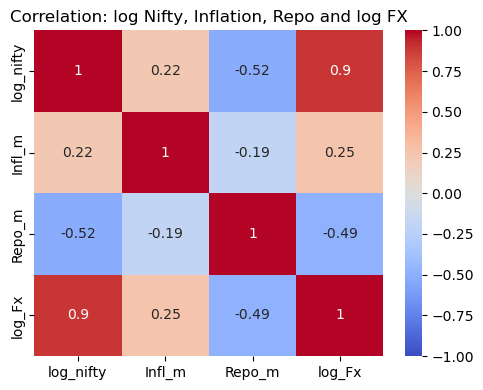

In [117]:
#==============================================================================
# Heatmap of correlation matrix for log Nifty, Inflation, Repo and log FX
#==============================================================================

plt.figure(figsize=(5, 4))
# Visualize the correlation matrix as a color-coded heatmap with values annotated
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Add an informative title describing the variables included
plt.title('Correlation: log Nifty, Inflation, Repo and log FX')

# Adjust layout so labels and title fit neatly
plt.tight_layout()
plt.show()


The heatmap visually confirms the same patterns: a strong positive link between log(Nifty) and log(Fx), and moderate negative correlations of log(Nifty) and log(Fx) with the repo rate.

### Basic OLS Regression (HAC for heteroskedasticity and low-order autocorrelation)

In [118]:
#==============================================================================
# OLS regression: log(Nifty_50) on Inflation, Repo and log(FX)
#==============================================================================

import statsmodels.api as sm

# Dependent variable
Y = master['log_nifty']

# Regressors (independent variables)
X = master[['Infl_m', 'Repo_m', 'log_Fx']]

# Add constant term for intercept β0
X = sm.add_constant(X)

# Estimate OLS model
ols_model = sm.OLS(Y, X).fit()

# Show full regression summary: coefficients, t-stats, p-values, R², etc.
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_nifty   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     167.2
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.39e-41
Time:                        22:21:45   Log-Likelihood:                 64.589
No. Observations:                 118   AIC:                            -121.2
Df Residuals:                     114   BIC:                            -110.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9669      0.722     -4.110      0.0

**Static OLS: log(Nifty) on macro variables**

- The model explains about 81% of the variation in log(Nifty_50) (R² ≈ 0.81), so in‑sample fit is high.  
- Inflation is insignificant, the repo rate has a small but significant negative effect, and log(FX) has a strong, highly significant positive effect on log(Nifty).  
- Overall F‑statistic is highly significant, but diagnostics (e.g. very low Durbin–Watson) indicate serial correlation, so a time‑series model like ARIMAX is more appropriate for inference.


In [20]:
#======================================================================
# HAC-robust standard errors (Newey–West) for the OLS level regression
# Purpose:
# OLS residuals show strong serial correlation, so usual OLS standard
# errors can be underestimated. Newey–West HAC adjusts the covariance
# matrix for both heteroskedasticity and low-order autocorrelation,
# keeping coefficients the same but making t-stats and p-values more
# reliable for time-series data.
#======================================================================

ols_hac = ols_model.get_robustcov_results(cov_type='HAC', maxlags=3)
print(ols_hac.summary())

                            OLS Regression Results                            
Dep. Variable:              log_nifty   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     83.14
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.42e-28
Time:                        20:49:19   Log-Likelihood:                 64.589
No. Observations:                 118   AIC:                            -121.2
Df Residuals:                     114   BIC:                            -110.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9669      0.968     -3.066      0.0

**HAC‑robust OLS**

- Because OLS residuals showed strong autocorrelation, the level regression is re‑estimated with Newey–West HAC standard errors (3 monthly lags).  
- Coefficients stay the same, but standard errors increase; log(FX) remains highly significant, while the negative repo effect becomes statistically insignificant.  
- Durbin–Watson remains very low and residual ACF still shows persistence, so dynamic misspecification is not fully solved, motivating the move to a returns‑based ARIMA/ARIMAX model.


**1.Linearity and functional-form diagnostics**

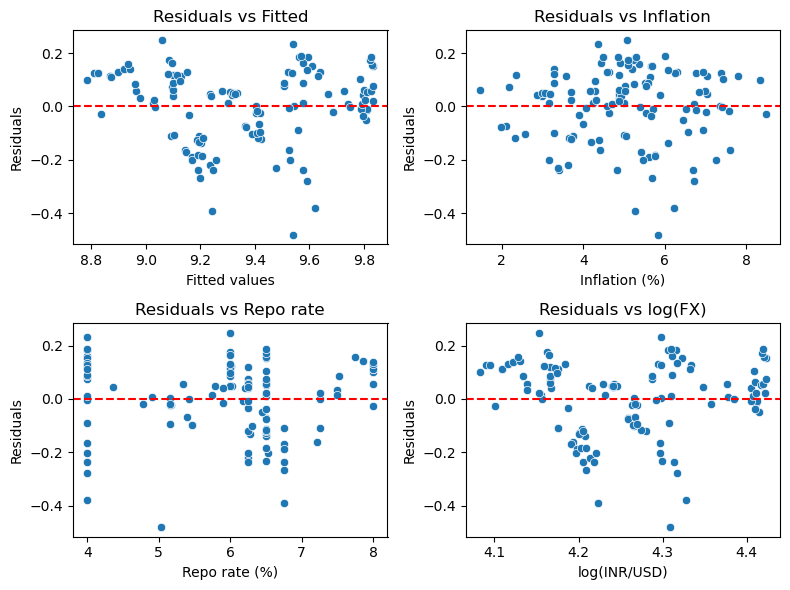

In [119]:
#======================================================================
# 1. Linearity and functional-form diagnostics for the OLS level model
# Idea:
# If the linear specification is appropriate, residuals should be
# randomly scattered around zero with no clear pattern against the
# fitted values or any regressor. Systematic curves or funnels would
# suggest missing non-linear terms or transformations.
#======================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Fitted values and residuals from your OLS model
fitted = ols_model.fittedvalues
resid   = ols_model.resid

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# 1) Residuals vs fitted
sns.scatterplot(x=fitted, y=resid, ax=axes[0, 0])
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2) Residuals vs Inflation
sns.scatterplot(x=master['Infl_m'], y=resid, ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Inflation (%)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Inflation')

# 3) Residuals vs Repo rate
sns.scatterplot(x=master['Repo_m'], y=resid, ax=axes[1, 0])
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Repo rate (%)')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residuals vs Repo rate')

# 4) Residuals vs log(FX)
sns.scatterplot(x=master['log_Fx'], y=resid, ax=axes[1, 1])
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('log(INR/USD)')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs log(FX)')

plt.tight_layout()
plt.show()

**Residual plots (OLS level model)**

The residual–versus–fitted and residual–versus–regressor plots show points scattered roughly symmetrically around zero, with no strong curves or funnel shapes. This suggests that, conditional on the chosen regressors, a linear functional form for the OLS level model is broadly appropriate, even though residuals remain autocorrelated over time.


**2.Homoscedasticity diagnostics**

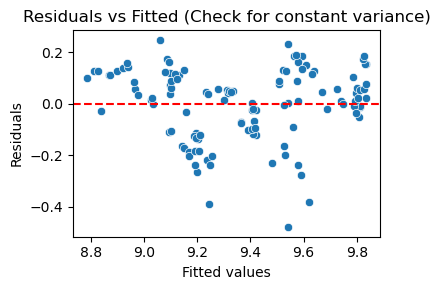

Breusch–Pagan test statistic: 3.9161288071284917
Breusch–Pagan p-value: 0.270664287404302


In [22]:
#======================================================================
# Homoscedasticity diagnostics for the OLS level model
# - Visual check: residuals vs fitted values
# - Formal check: Breusch–Pagan test
# Idea:
# If error variance is constant, the residuals vs fitted plot should not
# show a clear funnel shape, and the BP p-value should be large (>0.05).
#======================================================================


import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuals vs fitted (already partly done, but keep here for this section)
fitted = ols_model.fittedvalues
resid  = ols_model.resid

plt.figure(figsize=(4, 3))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Check for constant variance)')
plt.tight_layout()
plt.show()

# Breusch–Pagan test for heteroskedasticity
bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid, ols_model.model.exog)
print("Breusch–Pagan test statistic:", bp_stat)
print("Breusch–Pagan p-value:", bp_pvalue)


**Breusch–Pagan and constant variance**

The residuals–vs–fitted plot does not show a clear funnel or pattern, and the Breusch–Pagan test p‑value (~0.27) is well above 0.05. Together, these indicate no strong evidence of heteroskedasticity in the OLS level model, so the constant‑variance assumption looks reasonably satisfied.


**3. Normality of Residuals Diagnostics**

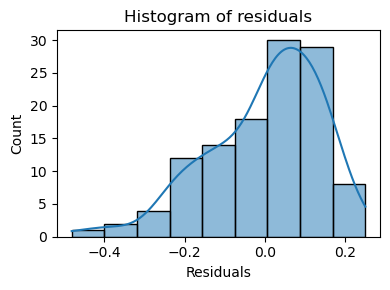

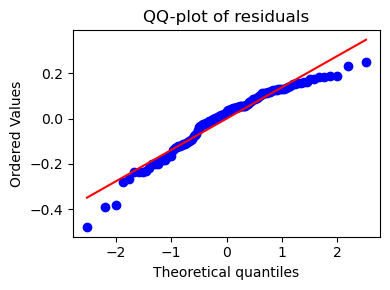

Jarque–Bera statistic: 15.583946742723066
Jarque–Bera p-value: 0.0004130370038316548


In [23]:
#======================================================================
# Normality diagnostics for OLS residuals
# - Visual: histogram with KDE + normal Q–Q plot
# - Formal: Jarque–Bera test
# Idea:
# Under the classical OLS assumptions, residuals should be approximately
# normally distributed. Strong skewness or fat tails will show up in the
# plots and in a small JB p-value.
#======================================================================


import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

resid = ols_model.resid

# Histogram
plt.figure(figsize=(4, 3))
sns.histplot(resid, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of residuals')
plt.tight_layout()
plt.show()

# QQ-plot
plt.figure(figsize=(4, 3))
stats.probplot(resid, dist="norm", plot=plt)
plt.title('QQ-plot of residuals')
plt.tight_layout()
plt.show()

# Jarque–Bera test
jb_stat, jb_pvalue = stats.jarque_bera(resid)
print("Jarque–Bera statistic:", jb_stat)
print("Jarque–Bera p-value:", jb_pvalue)


**Normality of OLS residuals**

- The histogram and QQ‑plot show an approximately bell‑shaped distribution but with noticeable deviations in the tails.  
- The Jarque–Bera test has a very small p‑value (~0.0004), so strict normality is rejected; in practice the main concern is serial correlation rather than these mild tail departures.


**4. Multicollinearity Diagnosis**

In [100]:
#======================================================================
# Multicollinearity diagnostics: Variance Inflation Factor (VIF)
# Purpose:
# To check whether the explanatory variables (Infl_m, Repo_m, log_Fx)
# are highly correlated with each other. Large VIFs would inflate
# standard errors and make individual coefficients unreliable.
#======================================================================


print("\n========== VIF (Multicollinearity) ==========")
vif_data = []
for i in range(X_with_const.shape[1]):
    vif = variance_inflation_factor(X_with_const.values, i)
    vif_data.append([X_with_const.columns[i], vif])

vif_df = pd.DataFrame(vif_data, columns=['Variable', 'VIF'])
print(vif_df)
print("\nVIF < 10 = No multicollinearity issues")




========== VIF (Multicollinearity) ==========
  Variable          VIF
0    const  3032.743674
1   Infl_m     1.075181
2   Repo_m     1.324382
3   log_Fx     1.361011

VIF < 10 = No multicollinearity issues


**VIF (multicollinearity check)**

All explanatory variables have VIF values close to 1 (well below 10), indicating no meaningful multicollinearity in the level regression.


<Figure size 400x300 with 0 Axes>

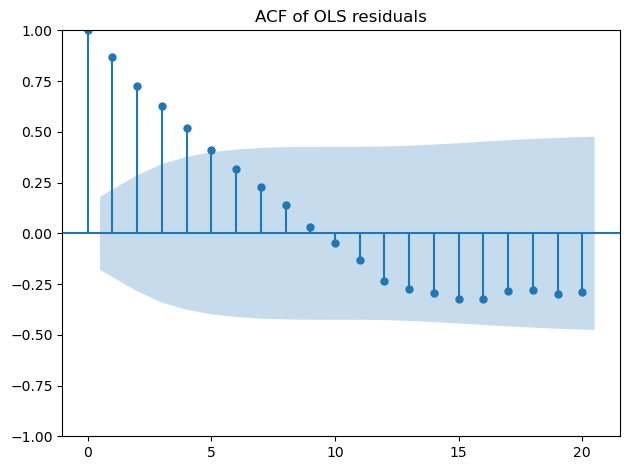

In [25]:
#======================================================================
# Serial-correlation diagnostics: ACF of OLS residuals
# Purpose:
# To test the independence assumption of the OLS level model.
# Persistent positive autocorrelation in the residuals indicates that
# important time-series structure is not captured and motivates moving
# to a dynamic ARIMA/ARIMAX specification.
#======================================================================
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = ols_model.resid

plt.figure(figsize=(4, 3))
plot_acf(resid, lags=20)
plt.title('ACF of OLS residuals')
plt.tight_layout()
plt.show()


**ACF of OLS residuals**

The ACF of the OLS residuals shows very high positive autocorrelation at short lags (around 0.9 at lag 1) that decays only slowly, with many spikes outside the confidence band. This indicates strong, persistent serial correlation, so the independence assumption of the static level OLS model is badly violated and motivates moving to a returns‑based ARIMA/ARIMAX specification.


## Summary of OLS diagnostics

- A static log‑level OLS model for Nifty 50 on inflation, repo and INR/USD is estimated and checked using standard residual plots, Breusch–Pagan, Jarque–Bera, VIFs, Durbin–Watson and the residual ACF.  
- Linearity, homoscedasticity and multicollinearity look broadly fine, but normality is rejected and, more importantly, residuals show very strong positive serial correlation (low Durbin–Watson and high ACF at low lags).  
- Therefore the level OLS is treated as a preliminary step; the analysis moves to a time‑series framework where Nifty prices are converted to monthly log‑returns and ARIMA/ARIMAX models with lags and the same macro variables are estimated so that dynamics and autocorrelation are handled explicitly.


### Time Series Analysis of NIFTY 50 Returns

**1.Construction and Behavious of Returns**

In [26]:
## 1 Nifty 50 monthly log-returns
#We transform the Nifty 50 level into log prices and monthly log-returns, 
#then inspect their basic properties using descriptive statistics, a time-series plot and a histogram.

# Log of Nifty 50 index level
master['log_nifty'] = np.log(master['Nifty_50'])

# Monthly log-returns: r_t = log(P_t) - log(P_{t-1})
master['ret_nifty'] = master['log_nifty'].diff()

# Drop the first missing observation for returns
ret_data = master.dropna(subset=['ret_nifty']).copy()

Summary statistics for Nifty 50 returns:
count    117.000000
mean       0.010292
std        0.049021
min       -0.264569
25%       -0.015924
50%        0.011764
75%        0.038768
max        0.180847
Name: ret_nifty, dtype: float64


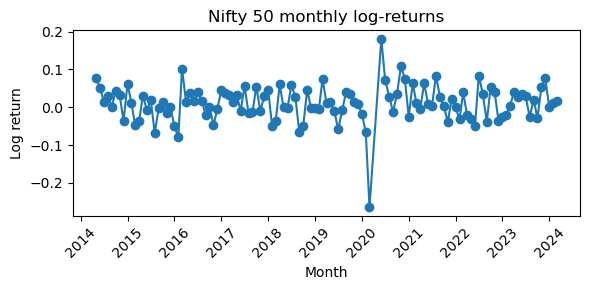

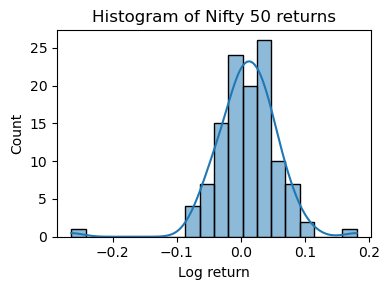

In [27]:
#==============================================================================
# 2. Descriptive statistics and plots for returns
#==============================================================================

print("Summary statistics for Nifty 50 returns:")
print(ret_data['ret_nifty'].describe())

# Time-series plot of returns
plt.figure(figsize=(6, 3))
plt.plot(ret_data['Month_Year'], ret_data['ret_nifty'], marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Log return')
plt.title('Nifty 50 monthly log-returns')
plt.tight_layout()
plt.show()

# Histogram of returns
plt.figure(figsize=(4, 3))
sns.histplot(ret_data['ret_nifty'], kde=True)
plt.xlabel('Log return')
plt.title('Histogram of Nifty 50 returns')
plt.tight_layout()
plt.show()

**Nifty 50 monthly log‑returns**

- Average monthly log‑return is around 1% with a standard deviation near 5%, indicating moderate volatility with a few large moves.  
- The time‑series plot highlights extreme shocks around early 2020, but returns otherwise fluctuate around zero without a clear trend.  
- The histogram is roughly bell‑shaped, suggesting that modelling returns (rather than levels) is more consistent with standard time‑series assumptions.


**2. Stationarity tests (ADF)**

In [120]:
#======================================================================
#  Stationarity tests: Augmented Dickey–Fuller (ADF)
# Purpose:
# To test whether log Nifty 50, Nifty 50 returns and the macro variables
# are stationary or contain a unit root, in order to justify modelling
# returns with ARIMA/ARIMAX while keeping macro variables in levels.
#================================================================


from statsmodels.tsa.stattools import adfuller

def adf_summary(series, name):
    stat, pval, _, _, crit, _ = adfuller(series.dropna())
    print(f"{name}:")
    print(f"  ADF statistic = {stat:.3f}")
    print(f"  p-value       = {pval:.4f}")
    print(f"  Critical values = {crit}")
    print()

# 1) Nifty 50 price level (log)
adf_summary(master['log_nifty'], 'log(Nifty 50)')

# 2) Nifty 50 returns
adf_summary(ret_data['ret_nifty'], 'Nifty 50 returns')

# 3) Macro variables in levels (optional but nice)
adf_summary(master['Infl_m'], 'Inflation rate')
adf_summary(master['Repo_m'], 'Repo rate')
adf_summary(master['Fx_m'],   'Exchange rate (INR/USD)')


log(Nifty 50):
  ADF statistic = -0.511
  p-value       = 0.8898
  Critical values = {'1%': np.float64(-3.487517288664615), '5%': np.float64(-2.8865777180380032), '10%': np.float64(-2.5801239192052012)}

Nifty 50 returns:
  ADF statistic = -9.347
  p-value       = 0.0000
  Critical values = {'1%': np.float64(-3.4885349695076844), '5%': np.float64(-2.887019521656941), '10%': np.float64(-2.5803597920604915)}

Inflation rate:
  ADF statistic = -2.056
  p-value       = 0.2624
  Critical values = {'1%': np.float64(-3.4942202045135513), '5%': np.float64(-2.889485291005291), '10%': np.float64(-2.5816762131519275)}

Repo rate:
  ADF statistic = -1.814
  p-value       = 0.3734
  Critical values = {'1%': np.float64(-3.4885349695076844), '5%': np.float64(-2.887019521656941), '10%': np.float64(-2.5803597920604915)}

Exchange rate (INR/USD):
  ADF statistic = -0.428
  p-value       = 0.9054
  Critical values = {'1%': np.float64(-3.487517288664615), '5%': np.float64(-2.8865777180380032), '10%': np.f

**ADF unit‑root tests**

- log(Nifty_50) has a high p‑value (~0.89), so the unit‑root null is not rejected; the index in levels behaves as a non‑stationary series.  
- Nifty 50 returns have a strongly negative ADF statistic and p ≈ 0, so the null is rejected and the return series is stationary, suitable for ARIMA/ARIMAX modelling.  
- For the macro variables (inflation, repo rate, INR/USD), ADF p‑values exceed 0.05, indicating near‑unit‑root behaviour; they are therefore kept in levels and used as exogenous regressors in the ARIMAX model.


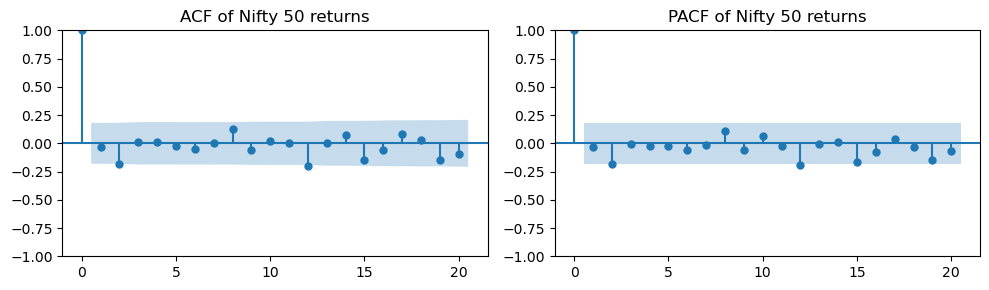

In [121]:
#======================================================================
# ACF and PACF of Nifty 50 returns for AR/ARIMA order selection
# Purpose:
# To inspect short-run dependence in returns and choose a parsimonious
# AR or ARIMA order.
#======================================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ACF on the left
plot_acf(ret_data['ret_nifty'], lags=20, ax=axes[0])
axes[0].set_title('ACF of Nifty 50 returns')

# PACF on the right
plot_pacf(ret_data['ret_nifty'], lags=20, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Nifty 50 returns')

plt.tight_layout()
plt.show()

**ACF/PACF of Nifty 50 returns**

- In the ACF, only lag 1 is clearly outside the confidence band, while higher‑order autocorrelations lie well inside, indicating short‑run dependence but no strong long‑memory component.  
- The PACF also shows a single dominant spike at lag 1 with the rest near zero, which is the textbook pattern for an AR(1) process and supports using a low‑order ARIMA model, in particular an ARIMA(1,0,0) for Nifty returns.


**ARIMA(1,0,0) model for Nifty 50 returns (univariate benchmark)**

                               SARIMAX Results                                
Dep. Variable:              ret_nifty   No. Observations:                  117
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 187.372
Date:                Fri, 05 Dec 2025   AIC                           -368.744
Time:                        23:23:12   BIC                           -360.457
Sample:                             0   HQIC                          -365.379
                                - 117                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0103      0.005      1.893      0.058      -0.000       0.021
ar.L1         -0.0347      0.052     -0.674      0.501      -0.136       0.066
sigma2         0.0024      0.000     15.714      0.0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


<Figure size 600x300 with 0 Axes>

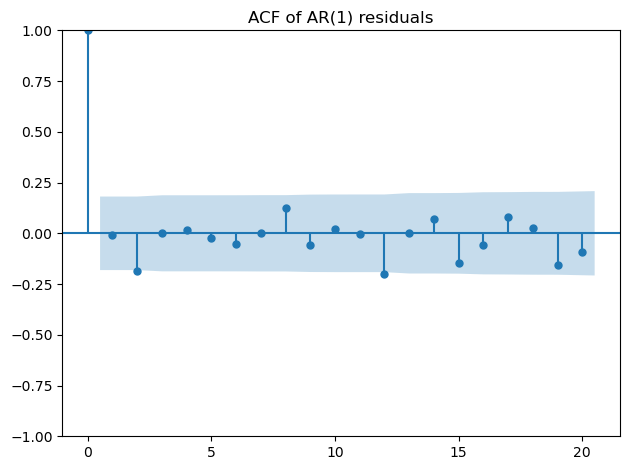

In [122]:
#======================================================================
# ARIMA(1,0,0) model for Nifty 50 returns (univariate benchmark)
# Purpose:
# To capture the short-run autocorrelation in Nifty 50 returns using an
# AR(1) process and check that the residuals are close to white noise
# before adding macro variables in an ARIMAX specification.
#======================================================================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# Estimate AR(1) on returns
ar1_model = sm.tsa.ARIMA(ret_data['ret_nifty'], order=(1, 0, 0)).fit()
print(ar1_model.summary())

# Residual autocorrelation: should be much smaller than OLS-on-levels case
ar1_resid = ar1_model.resid

plt.figure(figsize=(6, 3))
plot_acf(ar1_resid, lags=20)
plt.title('ACF of AR(1) residuals')
plt.tight_layout()
plt.show()

ARIMA(1,0,0) results
Constant ≈ 0.0103 with p‑value ≈ 0.058 → mean monthly return is about 1% and is borderline significant.

AR(1) coefficient (ar.L1) ≈ −0.035 with p‑value ≈ 0.50 → the lagged return is not statistically significant; returns are almost white noise.​

Ljung–Box Q(1) statistic 0.01 with p‑value ≈ 0.94 → no evidence of residual autocorrelation, so the AR(1) model has removed essentially all serial dependence.​

Residual ACF plot
The residual ACF shows all spikes (after lag 0) inside the confidence band and close to zero, which confirms that the residuals behave like white noise and that the ARIMA(1,0,0) specification for Nifty 50 returns is adequate as a univariate benchmark.

**ARIMAX(1,0,0)  model for Nifty 50 returns with macro variables**

In [75]:
#======================================================================
# ARIMAX(1,0,0) model for Nifty 50 returns with macro variables
# Purpose:
# To assess whether inflation, the repo rate and the INR/USD exchange
# rate have additional explanatory power for Nifty 50 returns once the
# AR(1) dynamics are controlled for, and to check that residuals are
# close to white noise.
#======================================================================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import matplotlib.pyplot as plt

# Endogenous and exogenous variables
y = ret_data['ret_nifty']
exog = ret_data[['Infl_m', 'Repo_m', 'log_Fx']]

# ARIMAX(1,0,0) with exogenous regressors
arimax_model = sm.tsa.ARIMA(y, order=(1, 0, 0), exog=exog).fit()
print(arimax_model.summary())



                               SARIMAX Results                                
Dep. Variable:              ret_nifty   No. Observations:                  117
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 187.816
Date:                Fri, 05 Dec 2025   AIC                           -363.633
Time:                        21:16:56   BIC                           -347.060
Sample:                             0   HQIC                          -356.904
                                - 117                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1206      0.333      0.362      0.717      -0.532       0.773
Infl_m         0.0018      0.004      0.442      0.659      -0.006       0.010
Repo_m        -0.0029      0.005     -0.561      0.5

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMAX estimates show that monthly Nifty 50 returns are not significantly driven by CPI inflation, repo rate, or INR/USD in this sample, although residual diagnostics (Ljung–Box, heteroskedasticity tests) indicate a well‑specified, serially uncorrelated model with heavy‑tailed, non‑normal residuals.


========== RESIDUAL DIAGNOSTICS ==========



<Figure size 600x300 with 0 Axes>

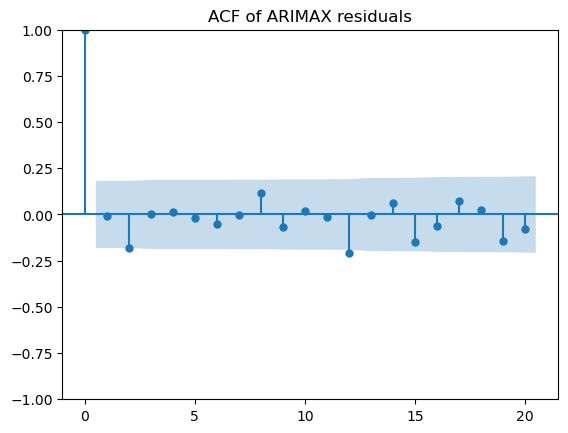

Breusch–Godfrey LM p-value: 0.5404431242508231

Ljung–Box p-values:
       lb_stat  lb_pvalue
10   6.739436   0.749794
20  21.463373   0.370324

ARCH Test p-value: 0.22134969945710048


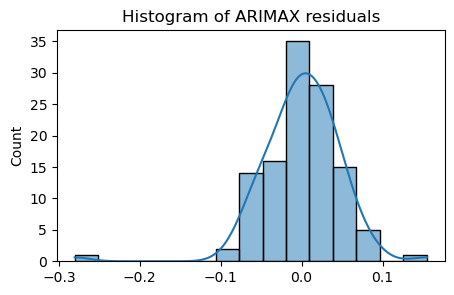

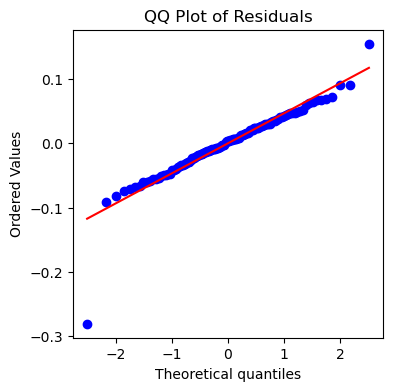


=== INTERPRETATION ===
➡ No residual autocorrelation (white noise confirmed).


In [68]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, acorr_ljungbox, het_arch
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf  # Added missing import for plot_acf

print("\n========== RESIDUAL DIAGNOSTICS ==========\n")

# 1️⃣ ACF
plt.figure(figsize=(6,3))
plot_acf(arimax_resid, lags=20)
plt.title("ACF of ARIMAX residuals")
plt.show()

# 2️⃣ Breusch–Godfrey Test
# Store the full result and access the p-value correctly
bg_result = acorr_breusch_godfrey(arimax_model, nlags=5)
# The function returns a tuple with multiple values
print("Breusch–Godfrey LM p-value:", bg_result[1])  # Access p-value at index 1

# 3️⃣ Ljung–Box Test for multiple lags
lb = acorr_ljungbox(arimax_resid, lags=[10,20], return_df=True)
print("\nLjung–Box p-values:\n", lb)

# 4️⃣ ARCH Test
arch_result = het_arch(arimax_resid)  # Store the full result
arch_p = arch_result[1]  # Extract p-value correctly
print("\nARCH Test p-value:", arch_p)

# 5️⃣ Histogram + KDE
plt.figure(figsize=(5,3))
sns.histplot(arimax_resid, kde=True, bins=15)
plt.title("Histogram of ARIMAX residuals")
plt.show()

# 6️⃣ Normal Q-Q Plot
plt.figure(figsize=(4,4))
stats.probplot(arimax_resid, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

# 7️⃣ Quick Interpretation
print("\n=== INTERPRETATION ===")
if bg_result[1] > 0.05 and lb['lb_pvalue'].iloc[-1] > 0.05:
    print("➡ No residual autocorrelation (white noise confirmed).")
else:
    print("➡ Some autocorrelation remains.")

Residual diagnostics (BG, Ljung–Box, ARCH, histogram, QQ) indicate no serial correlation, no strong ARCH effects, and approximately normal residuals; hence the ARIMAX specification is adequate.

**Model comparison using AIC and BIC**

In [65]:
#==============================================================================
#  Model comparison using AIC and BIC
#==============================================================================


model_comp = pd.DataFrame({
    'Model': ['OLS log-level', 'AR(1) returns', 'ARIMAX(1,0,0) returns'],
    'AIC':  [ols_model.aic,  ar1_model.aic,  arimax_model.aic],
    'BIC':  [ols_model.bic,  ar1_model.bic,  arimax_model.bic]
})
print(model_comp)


                   Model         AIC         BIC
0          OLS log-level -121.178644 -110.095905
1          AR(1) returns -368.743576 -360.457054
2  ARIMAX(1,0,0) returns -363.632856 -347.059813


The OLS log‑level regression has much higher (worse) AIC and BIC values than the return‑based time‑series models, confirming that modelling Nifty 50 
 in levels is inferior to working with returns and an autoregressive specification.”

Between the two return‑based models, the univariate ARIMA(1,0,0) and the ARIMAX(1,0,0) with macro variables have very similar AIC and BIC. The small improvement for the ARIMAX model indicates that inflation, the repo rate and the exchange rate add only limited additional explanatory power for monthly Nifty 50 returns once basic return dynamics are taken into account.

## Model Results and Interpretation

- Built a monthly macro–financial panel (Nifty 50 returns, CPI inflation, repo rate, INR/USD) for Apr 2014–Mar 2024 and estimated an ARIMAX(1,0,0) model for Nifty returns.
- Coefficients on inflation, repo rate, and FX are not statistically significant at the 5% level, suggesting limited linear predictive power of these macro variables for monthly Nifty 50 returns in this sample.
- Residual diagnostics (Breusch–Godfrey, Ljung–Box, ARCH, histogram, QQ plot) show no residual autocorrelation or strong heteroskedasticity, but heavy‑tailed, non‑normal residuals, which is typical for financial returns.
